In [18]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report,
)

pd.set_option("display.max_columns", None)
plt.style.use("seaborn-v0_8")
plt.rcParams["font.family"] = "DejaVu Sans"

In [19]:
DATA_PATH = "data/CIC_IDS2017_sampled.csv"

RANDOM_STATE = 42
VAL_SIZE = 0.2
PERCENTILE = 98

In [20]:
df = pd.read_csv(DATA_PATH)
df.columns = [c.strip() for c in df.columns]

print("Original shape:", df.shape)
df.head()

Original shape: (566195, 81)


,Destination Port,Flow Duration,Total Fwd Packets,Total Backward Packets,Total Length of Fwd Packets,Total Length of Bwd Packets,Fwd Packet Length Max,Fwd Packet Length Min,Fwd Packet Length Mean,Fwd Packet Length Std,Bwd Packet Length Max,Bwd Packet Length Min,Bwd Packet Length Mean,Bwd Packet Length Std,Flow Bytes/s,Flow Packets/s,Flow IAT Mean,Flow IAT Std,Flow IAT Max,Flow IAT Min,Fwd IAT Total,Fwd IAT Mean,Fwd IAT Std,Fwd IAT Max,Fwd IAT Min,Bwd IAT Total,Bwd IAT Mean,Bwd IAT Std,Bwd IAT Max,Bwd IAT Min,Fwd PSH Flags,Bwd PSH Flags,Fwd URG Flags,Bwd URG Flags,Fwd Header Length,Bwd Header Length,Fwd Packets/s,Bwd Packets/s,Min Packet Length,Max Packet Length,Packet Length Mean,Packet Length Std,Packet Length Variance,FIN Flag Count,SYN Flag Count,RST Flag Count,PSH Flag Count,ACK Flag Count,URG Flag Count,CWE Flag Count,ECE Flag Count,Down/Up Ratio,Average Packet Size,Avg Fwd Segment Size,Avg Bwd Segment Size,Fwd Header Length.1,Fwd Avg Bytes/Bulk,Fwd Avg Packets/Bulk,Fwd Avg Bulk Rate,Bwd Avg Bytes/Bulk,Bwd Avg Packets/Bulk,Bwd Avg Bulk Rate,Subflow Fwd Packets,Subflow Fwd Bytes,Subflow Bwd Packets,Subflow Bwd Bytes,Init_Win_bytes_forward,Init_Win_bytes_backward,act_data_pkt_fwd,min_seg_size_forward,Active Mean,Active Std,Active Max,Active Min,Idle Mean,Idle Std,Idle Max,Idle Min,Label,source_file,is_attack
0,40474,7182757,1,5,6,30,6,6,6.0,0.000000,6,6,6.000000,0.00000,5.012003,0.835334,1.436551e+06,3.186980e+06,7137556,0,0,0.00000,0.000000e+00,0,0,7164811,1791202.75,3.564259e+06,7137556,0,0,0,0,0,20,100,0.139222,0.696112,6,6,6.000000,0.000000,0.0000,0,0,0,0,1,1,0,0,5,7.000000,6.0,6.000000,20,0,0,0,0,0,0,1,6,5,30,229,0,0,20,45201.000,0.000,45201,45201,7137556.0,0.00,7137556,7137556,BENIGN,Friday-WorkingHours-Afternoon-DDos.pcap_ISCX.csv,0
1,28907,938509,1,5,6,30,6,6,6.0,0.000000,6,6,6.000000,0.00000,38.358716,6.393119,1.877018e+05,4.098531e+05,920834,6,0,0.00000,0.000000e+00,0,0,929015,232253.75,4.590645e+05,920834,6,0,0,0,0,20,100,1.065520,5.327599,6,6,6.000000,0.000000,0.0000,0,0,0,0,1,1,0,0,5,7.000000,6.0,6.000000,20,0,0,0,0,0,0,1,6,5,30,229,0,0,20,0.000,0.000,0,0,0.0,0.00,0,0,BENIGN,Friday-WorkingHours-Afternoon-DDos.pcap_ISCX.csv,0
2,0,119995732,123,0,0,0,0,0,0.0,0.000000,0,0,0.000000,0.00000,0.000000,1.025036,9.835716e+05,3.395926e+06,26300000,0,120000000,983571.57380,3.395926e+06,26300000,0,0,0.00,0.000000e+00,0,0,0,0,0,0,0,0,1.025036,0.000000,0,0,0.000000,0.000000,0.0000,0,0,0,0,0,0,0,0,0,0.000000,0.0,0.000000,0,0,0,0,0,0,0,123,0,0,0,-1,-1,0,0,3753432.167,5183854.063,13200000,1,13100000.0,6507819.26,26300000,6484077,BENIGN,Friday-WorkingHours-Afternoon-DDos.pcap_ISCX.csv,0
3,443,142954,10,6,553,3949,196,0,55.3,71.704719,2860,0,658.166667,1111.62915,31492.647980,111.924115,9.530267e+03,1.529768e+04,37502,3,142954,15883.77778,1.769110e+04,39066,49,85183,17036.60,2.273564e+04,45741,3,0,0,0,0,212,132,69.952572,41.971543,0,2860,264.823529,692.022239,478894.7794,0,0,0,1,0,0,0,0,0,281.375000,55.3,658.166667,212,0,0,0,0,0,0,10,553,6,3949,8192,343,9,20,0.000,0.000,0,0,0.0,0.00,0,0,BENIGN,Friday-WorkingHours-Afternoon-DDos.pcap_ISCX.csv,0
4,17541,2548725,1,6,6,36,6,6,6.0,0.000000,6,6,6.000000,0.00000,16.478828,2.746471,4.247875e+05,1.036908e+06,2541367,1,0,0.00000,0.000000e+00,0,0,2546294,509258.80,1.135983e+06,2541367,1,0,0,0,0,20,120,0.392353,2.354118,6,6,6.000000,0.000000,0.0000,0,0,0,0,1,1,0,0,6,6.857143,6.0,6.000000,20,0,0,0,0,0,0,1,6,6,36,229,0,0,20,0.000,0.000,0,0,0.0,0.00,0,0,BENIGN,Friday-WorkingHours-Afternoon-DDos.pcap_ISCX.csv,0


In [21]:
label_candidates = [c for c in df.columns if c.lower() == "label"]

if len(label_candidates) == 0:
    raise ValueError("Label column was not found.")

label_col = label_candidates[0]
print("Label column:", label_col)

df[label_col] = df[label_col].astype(str)
df[label_col] = df[label_col].str.replace("�", "-", regex=False)
df[label_col] = df[label_col].str.strip()

# target: 0 = BENIGN, 1 = útok
df["target"] = (df[label_col] != "BENIGN").astype(int)

print("Target distribution:")
print(df["target"].value_counts())

Label column: Label
Target distribution:
target
0    454616
1    111579
Name: count, dtype: int64


In [22]:
numeric_cols = df.select_dtypes(include=[np.number]).columns.tolist()

feature_cols = [
    c for c in numeric_cols
    if c.lower() != "target"
    and "label" not in c.lower()
    and "attack" not in c.lower()
]

removed_cols = [c for c in numeric_cols if c not in feature_cols]

print("All numeric columns:", len(numeric_cols))
print("Feature columns used for modeling:", len(feature_cols))
print("Removed columns:", removed_cols)

All numeric columns: 80
Feature columns used for modeling: 78
Removed columns: ['is_attack', 'target']


In [23]:
df[feature_cols] = df[feature_cols].replace([np.inf, -np.inf], np.nan)

before_drop = df.shape[0]
df = df.dropna(subset=feature_cols).reset_index(drop=True)
after_drop = df.shape[0]

print(f"Rows removed during cleaning: {before_drop - after_drop}")
print("Cleaned shape:", df.shape)

Rows removed during cleaning: 562
Cleaned shape: (565633, 82)


In [24]:
X = df[feature_cols].copy()
y = df["target"].values.astype(int)

print("X shape:", X.shape)
print("y shape:", y.shape)
print("Class distribution:", np.bincount(y))

X shape: (565633, 78)
y shape: (565633,)
Class distribution: [454277 111356]


In [25]:
normal_mask = (y == 0)

X_normal = X.loc[normal_mask].copy()

X_train, X_val = train_test_split(
    X_normal,
    test_size=VAL_SIZE,
    random_state=RANDOM_STATE,
    shuffle=True
)

X_test = X.copy()
y_test = y.copy()

print("X_train shape:", X_train.shape)
print("X_val shape:", X_val.shape)
print("X_test shape:", X_test.shape)
print("y_test shape:", y_test.shape)

X_train shape: (363421, 78)
X_val shape: (90856, 78)
X_test shape: (565633, 78)
y_test shape: (565633,)


In [26]:
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_val_scaled = scaler.transform(X_val)
X_test_scaled = scaler.transform(X_test)

X_train_scaled = np.nan_to_num(X_train_scaled, nan=0.0, posinf=0.0, neginf=0.0)
X_val_scaled = np.nan_to_num(X_val_scaled, nan=0.0, posinf=0.0, neginf=0.0)
X_test_scaled = np.nan_to_num(X_test_scaled, nan=0.0, posinf=0.0, neginf=0.0)

print("Scaled train shape:", X_train_scaled.shape)
print("Scaled val shape:", X_val_scaled.shape)
print("Scaled test shape:", X_test_scaled.shape)

Scaled train shape: (363421, 78)
Scaled val shape: (90856, 78)
Scaled test shape: (565633, 78)


In [27]:
CLIP_VALUE = 50

X_train_vae = np.clip(X_train_scaled.astype("float32"), -CLIP_VALUE, CLIP_VALUE)
X_val_vae = np.clip(X_val_scaled.astype("float32"), -CLIP_VALUE, CLIP_VALUE)
X_test_vae = np.clip(X_test_scaled.astype("float32"), -CLIP_VALUE, CLIP_VALUE)

print("Clip value:", CLIP_VALUE)
print("VAE train range:", X_train_vae.min(), X_train_vae.max())
print("VAE val range:", X_val_vae.min(), X_val_vae.max())
print("VAE test range:", X_test_vae.min(), X_test_vae.max())

print("NaN train:", np.isnan(X_train_vae).sum())
print("NaN val:", np.isnan(X_val_vae).sum())
print("NaN test:", np.isnan(X_test_vae).sum())

print("Inf train:", np.isinf(X_train_vae).sum())
print("Inf val:", np.isinf(X_val_vae).sum())
print("Inf test:", np.isinf(X_test_vae).sum())

Clip value: 50
VAE train range: -50.0 50.0
VAE val range: -50.0 50.0
VAE test range: -50.0 50.0
NaN train: 0
NaN val: 0
NaN test: 0
Inf train: 0
Inf val: 0
Inf test: 0


In [28]:
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers

tf.keras.utils.set_random_seed(RANDOM_STATE)

EPOCHS = 10
BATCH_SIZE = 256

input_dim = X_train_vae.shape[1]
latent_dim = 8
BETA = 0.0001

class Sampling(layers.Layer):
    def call(self, inputs):
        z_mean, z_log_var = inputs
        z_log_var = tf.clip_by_value(z_log_var, -5.0, 5.0)
        epsilon = tf.random.normal(shape=tf.shape(z_mean))
        return z_mean + tf.exp(0.5 * z_log_var) * epsilon

inputs = keras.Input(shape=(input_dim,))

h = layers.Dense(64, activation="relu")(inputs)
h = layers.Dense(32, activation="relu")(h)

z_mean = layers.Dense(latent_dim)(h)
z_log_var = layers.Dense(latent_dim)(h)
z = Sampling()([z_mean, z_log_var])

encoder = keras.Model(inputs, [z_mean, z_log_var, z], name="encoder")

latent_inputs = keras.Input(shape=(latent_dim,))

h = layers.Dense(32, activation="relu")(latent_inputs)
h = layers.Dense(64, activation="relu")(h)
outputs = layers.Dense(input_dim, activation="linear")(h)

decoder = keras.Model(latent_inputs, outputs, name="decoder")

class VAE(keras.Model):
    def __init__(self, encoder, decoder, beta=0.0001, **kwargs):
        super().__init__(**kwargs)
        self.encoder = encoder
        self.decoder = decoder
        self.beta = beta

    def train_step(self, data):
        if isinstance(data, tuple):
            data = data[0]

        with tf.GradientTape() as tape:
            z_mean, z_log_var, z = self.encoder(data)
            z_log_var = tf.clip_by_value(z_log_var, -5.0, 5.0)

            reconstruction = self.decoder(z)

            reconstruction_loss = tf.reduce_mean(tf.square(data - reconstruction))

            kl_loss = -0.5 * tf.reduce_mean(
                1 + z_log_var - tf.square(z_mean) - tf.exp(z_log_var)
            )

            total_loss = reconstruction_loss + self.beta * kl_loss

        grads = tape.gradient(total_loss, self.trainable_weights)
        grads = [tf.clip_by_norm(g, 1.0) if g is not None else None for g in grads]
        self.optimizer.apply_gradients(zip(grads, self.trainable_weights))

        return {
            "loss": total_loss,
            "recon_loss": reconstruction_loss,
            "kl_loss": kl_loss,
        }

model = VAE(encoder, decoder, beta=BETA)

model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=1e-5)
)

history = model.fit(
    X_train_vae,
    epochs=EPOCHS,
    batch_size=BATCH_SIZE,
    shuffle=True,
    verbose=1
)

Epoch 1/10
1420/1420 ━━━━━━━━━━━━━━━━━━━━ 17s 8ms/step - kl_loss: 0.1799 - loss: 0.5978 - recon_loss: 0.5978
Epoch 2/10
1420/1420 ━━━━━━━━━━━━━━━━━━━━ 20s 8ms/step - kl_loss: 0.3311 - loss: 0.5600 - recon_loss: 0.5600
Epoch 3/10
1420/1420 ━━━━━━━━━━━━━━━━━━━━ 20s 8ms/step - kl_loss: 1.0031 - loss: 0.4313 - recon_loss: 0.4312
Epoch 4/10
1420/1420 ━━━━━━━━━━━━━━━━━━━━ 21s 8ms/step - kl_loss: 1.7302 - loss: 0.3518 - recon_loss: 0.3516
Epoch 5/10
1420/1420 ━━━━━━━━━━━━━━━━━━━━ 21s 8ms/step - kl_loss: 2.4462 - loss: 0.2992 - recon_loss: 0.2989
Epoch 6/10
1420/1420 ━━━━━━━━━━━━━━━━━━━━ 11s 8ms/step - kl_loss: 3.1990 - loss: 0.2592 - recon_loss: 0.2589
Epoch 7/10
1420/1420 ━━━━━━━━━━━━━━━━━━━━ 21s 8ms/step - kl_loss: 3.9398 - loss: 0.2285 - recon_loss: 0.2281
Epoch 8/10
1420/1420 ━━━━━━━━━━━━━━━━━━━━ 21s 8ms/step - kl_loss: 4.6647 - loss: 0.2046 - recon_loss: 0.2041
Epoch 9/10
1420/1420 ━━━━━━━━━━━━━━━━━━━━ 21s 8ms/step - kl_loss: 5.3756 - loss: 0.1856 - recon_loss: 0.1851
Epoch 10/10
1420/14

In [29]:
z_mean_val, z_log_var_val, z_val = encoder.predict(X_val_vae, verbose=0)
X_val_pred = decoder.predict(z_mean_val, verbose=0)
scores_val = np.mean((X_val_vae - X_val_pred) ** 2, axis=1)

z_mean_test, z_log_var_test, z_test = encoder.predict(X_test_vae, verbose=0)
X_test_pred = decoder.predict(z_mean_test, verbose=0)
scores_test = np.mean((X_test_vae - X_test_pred) ** 2, axis=1)

print("Validation score range:", scores_val.min(), scores_val.max())
print("Test score range:", scores_test.min(), scores_test.max())

print("NaN in scores_val:", np.isnan(scores_val).sum())
print("NaN in scores_test:", np.isnan(scores_test).sum())

print("Inf in scores_val:", np.isinf(scores_val).sum())
print("Inf in scores_test:", np.isinf(scores_test).sum())

Validation score range: 0.0005712449 240.70628
Test score range: 0.0005666506 360.911
NaN in scores_val: 0
NaN in scores_test: 0
Inf in scores_val: 0
Inf in scores_test: 0


In [30]:
from sklearn.metrics import roc_curve, auc

fpr, tpr, roc_thresholds = roc_curve(y_test, scores_test)
roc_auc = auc(fpr, tpr)

PERCENTILES = [99, 98, 95, 90, 85, 80, 70, 60, 50]

results = []

for p in PERCENTILES:
    threshold = np.percentile(scores_val, p)
    y_pred_p = (scores_test >= threshold).astype(int)

    acc_p = accuracy_score(y_test, y_pred_p)
    prec_p = precision_score(y_test, y_pred_p, zero_division=0)
    rec_p = recall_score(y_test, y_pred_p, zero_division=0)
    f1_p = f1_score(y_test, y_pred_p, zero_division=0)

    results.append({
        "Percentil": p,
        "Threshold": threshold,
        "Precision": prec_p,
        "Recall": rec_p,
        "F1-score": f1_p,
        "Accuracy": acc_p,
        "AUC": roc_auc,
        "Predicted anomalies": int(y_pred_p.sum())
    })

results_df = pd.DataFrame(results)
results_df

,Percentil,Threshold,Precision,Recall,F1-score,Accuracy,AUC,Predicted anomalies
0,99,3.026055,0.870165,0.270717,0.412959,0.848474,0.830592,34644
1,98,1.351492,0.826048,0.379108,0.519703,0.862048,0.830592,51106
2,95,0.604704,0.685105,0.443119,0.538161,0.850270,0.830592,72024
3,90,0.314924,0.542189,0.488407,0.513895,0.818094,0.830592,100310
4,85,0.216549,0.451005,0.506529,0.477157,0.781464,0.830592,125065
5,80,0.175031,0.387284,0.517368,0.442973,0.743843,0.830592,148759
6,70,0.100546,0.376221,0.740661,0.498982,0.707183,0.830592,219225
7,60,0.072783,0.362327,0.925761,0.520816,0.664629,0.830592,284519
8,50,0.053270,0.328747,0.998976,0.494697,0.598231,0.830592,338382


In [31]:
threshold = np.percentile(scores_val, PERCENTILE)
y_pred = (scores_test >= threshold).astype(int)

print(f"Threshold (percentile={PERCENTILE}):", threshold)
print("Predicted anomalies:", int(y_pred.sum()))

Threshold (percentile=98): 1.3514923
Predicted anomalies: 51106


In [32]:
acc = accuracy_score(y_test, y_pred)
prec = precision_score(y_test, y_pred, zero_division=0)
rec = recall_score(y_test, y_pred, zero_division=0)
f1 = f1_score(y_test, y_pred, zero_division=0)
cm = confusion_matrix(y_test, y_pred)

print("=== VAE - CIC ===")
print(f"Accuracy : {acc:.4f}")
print(f"Precision: {prec:.4f}")
print(f"Recall   : {rec:.4f}")
print(f"F1-score : {f1:.4f}")

=== VAE - CIC ===
Accuracy : 0.8620
Precision: 0.8260
Recall   : 0.3791
F1-score : 0.5197


              precision    recall  f1-score   support

           0     0.8656    0.9804    0.9195    454277
           1     0.8260    0.3791    0.5197    111356

    accuracy                         0.8620    565633
   macro avg     0.8458    0.6798    0.7196    565633
weighted avg     0.8578    0.8620    0.8408    565633



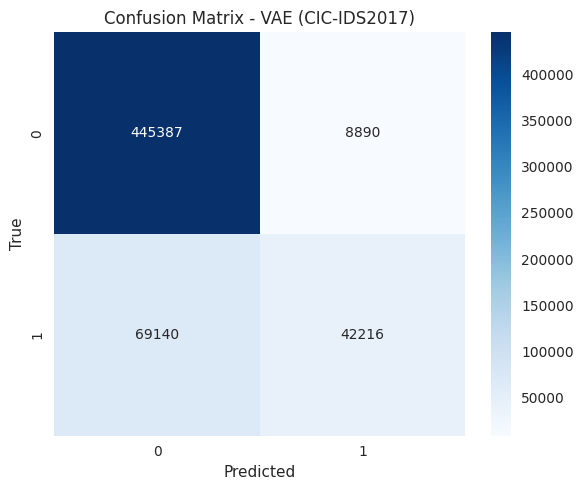

In [33]:
print(classification_report(y_test, y_pred, digits=4, zero_division=0))

plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
plt.title("Confusion Matrix - VAE (CIC-IDS2017)")
plt.xlabel("Predicted")
plt.ylabel("True")
plt.tight_layout()
plt.show()

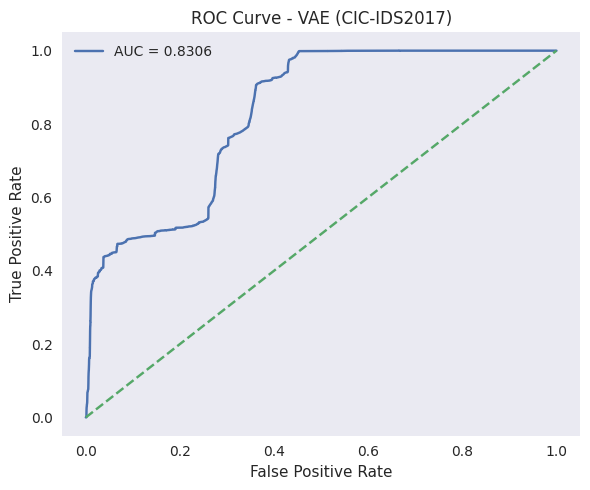

AUC: 0.8305918670796686


In [34]:
from sklearn.metrics import roc_curve, auc

fpr, tpr, roc_thresholds = roc_curve(y_test, scores_test)
roc_auc = auc(fpr, tpr)

plt.figure(figsize=(6, 5))
plt.plot(fpr, tpr, label=f"AUC = {roc_auc:.4f}")
plt.plot([0, 1], [0, 1], linestyle="--")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve - VAE (CIC-IDS2017)")
plt.legend()
plt.grid()
plt.tight_layout()
plt.show()

print("AUC:", roc_auc)